# BAF60 computeMatrix 结果检查

每一行对应一个通过 `q <= 0.05` 阈值的 MACS2 summit。前六列描述基因组区间，其余列是 summit 中心周围以 20 bp 为 bin 的 `log2(IP/Input)` 信号。

In [1]:
from pathlib import Path
import gzip, json
import pandas as pd

matrix_path = Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow/compute_matrix/BAF60.matrix.gz')
with gzip.open(matrix_path, 'rt') as f:
    metadata = json.loads(f.readline().removeprefix('@'))

bin_size = metadata['bin size'][0]
bin_starts = range(-metadata['upstream'][0], metadata['downstream'][0], bin_size)
columns = ['chrom', 'start', 'end', 'name', 'score', 'strand'] + [f'signal_{x}_{x + bin_size}' for x in bin_starts]
df = pd.read_csv(matrix_path, sep='\t', comment='@', header=None, names=columns)

print(df.columns.tolist())
df.head()

['chrom', 'start', 'end', 'name', 'score', 'strand', 'signal_-2000_-1980', 'signal_-1980_-1960', 'signal_-1960_-1940', 'signal_-1940_-1920', 'signal_-1920_-1900', 'signal_-1900_-1880', 'signal_-1880_-1860', 'signal_-1860_-1840', 'signal_-1840_-1820', 'signal_-1820_-1800', 'signal_-1800_-1780', 'signal_-1780_-1760', 'signal_-1760_-1740', 'signal_-1740_-1720', 'signal_-1720_-1700', 'signal_-1700_-1680', 'signal_-1680_-1660', 'signal_-1660_-1640', 'signal_-1640_-1620', 'signal_-1620_-1600', 'signal_-1600_-1580', 'signal_-1580_-1560', 'signal_-1560_-1540', 'signal_-1540_-1520', 'signal_-1520_-1500', 'signal_-1500_-1480', 'signal_-1480_-1460', 'signal_-1460_-1440', 'signal_-1440_-1420', 'signal_-1420_-1400', 'signal_-1400_-1380', 'signal_-1380_-1360', 'signal_-1360_-1340', 'signal_-1340_-1320', 'signal_-1320_-1300', 'signal_-1300_-1280', 'signal_-1280_-1260', 'signal_-1260_-1240', 'signal_-1240_-1220', 'signal_-1220_-1200', 'signal_-1200_-1180', 'signal_-1180_-1160', 'signal_-1160_-1140', '

,chrom,start,end,name,score,strand,signal_-2000_-1980,signal_-1980_-1960,signal_-1960_-1940,signal_-1940_-1920,...,signal_1800_1820,signal_1820_1840,signal_1840_1860,signal_1860_1880,signal_1880_1900,signal_1900_1920,signal_1920_1940,signal_1940_1960,signal_1960_1980,signal_1980_2000
0,Chr1,18198,18199,Chr1:18198-18199,.,.,1.286365,-1.160889,-1.090970,-2.855915,...,0.527894,-2.026494,-1.990087,-2.009924,-2.687595,-0.848202,-0.805408,0.823847,2.279115,2.613129
1,Chr1,55407,55408,Chr1:55407-55408,.,.,-3.612891,-3.801084,-1.290003,0.041870,...,2.130731,0.343619,0.259388,-1.094276,0.052656,0.648646,1.040096,-0.351086,-2.510989,-3.040448
2,Chr1,68637,68638,Chr1:68637-68638,.,.,-2.056055,0.216041,0.465677,-0.294441,...,-0.548647,-0.498082,-2.954983,0.037379,0.803995,1.093562,-0.934032,-2.554880,-2.735178,-2.908939
3,Chr1,108140,108141,Chr1:108140-108141,.,.,1.512905,1.506475,1.167860,0.960246,...,-3.073125,-3.078485,-3.283310,-1.316585,-1.281295,-0.313498,0.013062,0.038621,-1.373646,-2.779555
4,Chr1,136082,136083,Chr1:136082-136083,.,.,-1.547692,-0.681531,-0.740163,-1.818045,...,-0.475403,-0.072776,-1.304329,-2.251832,-0.476568,0.106841,2.175033,3.305939,2.869367,0.488440


## Summit-centered heatmap 和 meta profile

保留全部检出的 summits，仅按照 summit 中心上下游 200 bp 内的平均信号对各行排序，不额外进行低信号过滤。

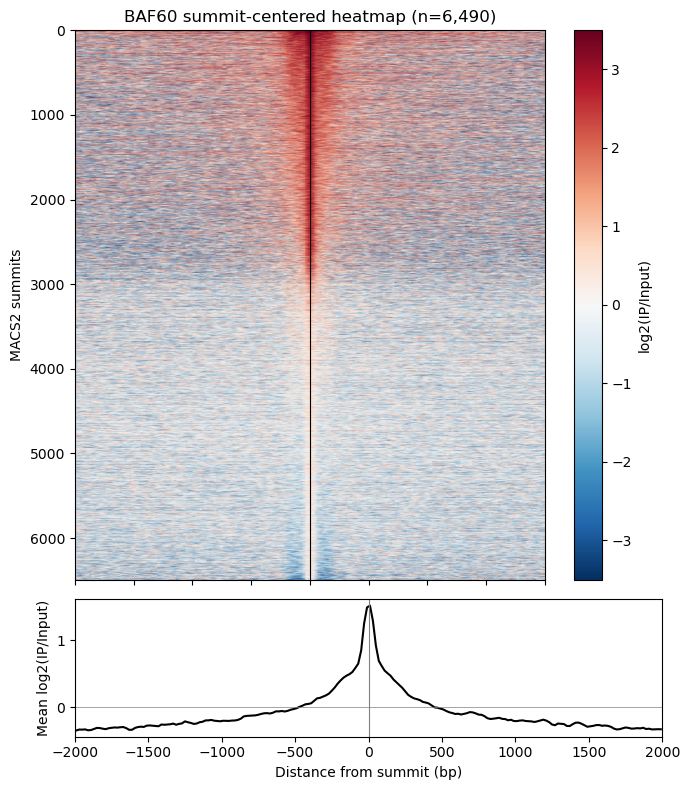

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-metadata['upstream'][0], metadata['downstream'][0], bin_size) + bin_size / 2
signal = df.iloc[:, 6:].to_numpy(float)
center = np.abs(x) <= 200
order = np.argsort(np.nanmean(signal[:, center], axis=1))[::-1]
color_limit = np.nanpercentile(np.abs(signal), 98)

fig, (ax_heatmap, ax_meta) = plt.subplots(2, 1, figsize=(7, 8), sharex=True, gridspec_kw={'height_ratios': [4, 1]})
image = ax_heatmap.imshow(signal[order], aspect='auto', cmap='RdBu_r', vmin=-color_limit, vmax=color_limit, extent=[-metadata['upstream'][0], metadata['downstream'][0], len(signal), 0])
ax_heatmap.axvline(0, color='black', lw=0.8)
ax_heatmap.set(ylabel='MACS2 summits', title=f'BAF60 summit-centered heatmap (n={len(signal):,})')
fig.colorbar(image, ax=ax_heatmap, label='log2(IP/Input)')

ax_meta.plot(x, np.nanmean(signal, axis=0), color='black')
ax_meta.axvline(0, color='grey', lw=0.8)
ax_meta.axhline(0, color='grey', lw=0.5)
ax_meta.set(xlabel='Distance from summit (bp)', ylabel='Mean log2(IP/Input)')
plt.tight_layout()

## MACS2 peaks 的 genomic annotation

使用完整的 `narrowPeak` 区间，以及 GTF 中的标准 `gene`/`exon` features。各分类互斥，优先级为 **Exon > Intron > strand-aware upstream 500 bp > Intergenic**。Genome fraction 使用完全相同的规则对 TAIR10 碱基进行分类。

In [3]:
gtf_path = Path('/data1/home/zhangzhhui03/workspace/reference/Araport11/Araport11_GTF_genes_transposons.20241001.gtf')
peak_path = Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow/macs2/BAF60/BAF60_peaks.narrowPeak')
chrom_sizes_path = Path('/data1/home/zhangzhhui03/workspace/repos/ChIP_workflow/config/TAIR10.chrom.sizes')

chrom_sizes = dict(pd.read_csv(chrom_sizes_path, sep='\t', header=None).itertuples(index=False, name=None))
gtf = pd.read_csv(gtf_path, sep='\t', comment='#', header=None, usecols=[0, 2, 3, 4, 6, 8],
                  names=['chrom', 'feature', 'start', 'end', 'strand', 'attribute'])
gtf['start'] -= 1  # GTF: 1-based inclusive -> BED/Python: 0-based half-open
gtf['gene_id'] = gtf['attribute'].str.extract(r'gene_id\s+([^;]+)', expand=False).str.replace(chr(34), '', regex=False)
genes = gtf[gtf['feature'] == 'gene']
exons = gtf[gtf['feature'] == 'exon']

# 0=Exon, 1=Intron, 2=Upstream 500, 3=Intergenic; later assignments have higher priority.
genome_label = {chrom: np.full(size, 3, dtype=np.uint8) for chrom, size in chrom_sizes.items()}
for chrom, start, end, strand in genes[['chrom', 'start', 'end', 'strand']].itertuples(index=False, name=None):
    if strand == '+':
        genome_label[chrom][max(0, start - 500):start] = 2
    else:
        genome_label[chrom][end:min(chrom_sizes[chrom], end + 500)] = 2
for chrom, start, end in genes[['chrom', 'start', 'end']].itertuples(index=False, name=None):
    genome_label[chrom][start:end] = 1
for chrom, start, end in exons[['chrom', 'start', 'end']].itertuples(index=False, name=None):
    genome_label[chrom][start:end] = 0

,Peaks,Peak %,Genome bp,Genome %
category,,,,
Exon,1609,24.79,57017315,47.65
Intron,112,1.73,18214322,15.22
Upstream 500,675,10.40,11085632,9.26
Intergenic,4094,63.08,33351365,27.87


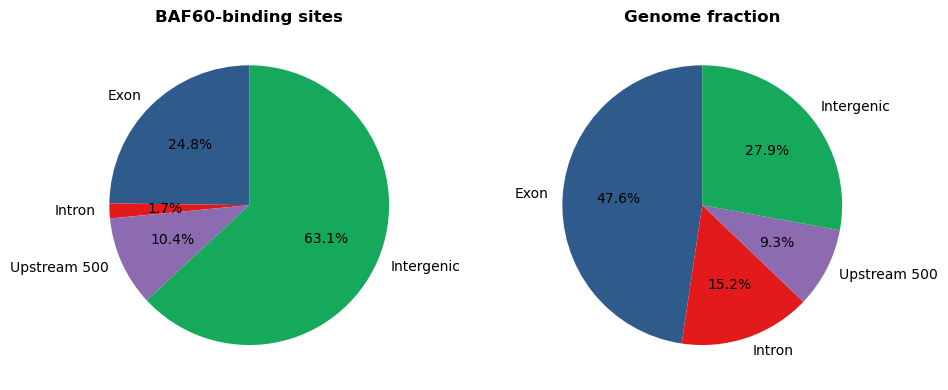

In [4]:
categories = ['Exon', 'Intron', 'Upstream 500', 'Intergenic']
peaks = pd.read_csv(peak_path, sep='\t', header=None, usecols=[0, 1, 2], names=['chrom', 'start', 'end'])
peaks['category'] = [categories[int(genome_label[c][s:e].min())] for c, s, e in peaks.itertuples(index=False, name=None)]
peak_counts = peaks['category'].value_counts().reindex(categories, fill_value=0)
genome_counts = sum((np.bincount(x, minlength=4) for x in genome_label.values()), np.zeros(4, dtype=np.int64))

summary = pd.DataFrame({'Peaks': peak_counts, 'Peak %': peak_counts / len(peaks) * 100,
                        'Genome bp': genome_counts, 'Genome %': genome_counts / genome_counts.sum() * 100})
display(summary.round(2))

colors = ['#2f5b8c', '#e31a1c', '#8c6bb1', '#16a85b']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, title in zip(axes, [peak_counts, genome_counts], ['BAF60-binding sites', 'Genome fraction']):
    ax.pie(values, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(title, fontweight='bold')
plt.tight_layout()

## Intergenic peaks 到最近 TSS 的距离

使用每个 intergenic peak 的中点，以及同一染色体上最近的 gene TSS。带符号距离以转录方向为准：负值表示 upstream，正值表示 downstream。

In [5]:
tss = genes[['chrom', 'start', 'end', 'strand', 'gene_id']].copy()
tss['tss'] = np.where(tss['strand'] == '+', tss['start'], tss['end'] - 1)
intergenic = peaks[peaks['category'] == 'Intergenic'].copy()
intergenic['midpoint'] = ((intergenic['start'] + intergenic['end']) // 2).astype(int)

nearest_parts = []
for chrom, peak_group in intergenic.groupby('chrom'):
    gene_group = tss[tss['chrom'] == chrom].sort_values('tss').reset_index(drop=True)
    positions = peak_group['midpoint'].to_numpy()
    tss_positions = gene_group['tss'].to_numpy()
    right = np.clip(np.searchsorted(tss_positions, positions), 0, len(tss_positions) - 1)
    left = np.clip(right - 1, 0, len(tss_positions) - 1)
    nearest = np.where(np.abs(tss_positions[right] - positions) < np.abs(tss_positions[left] - positions), right, left)
    selected = gene_group.iloc[nearest]
    nearest_parts.append(pd.DataFrame({'nearest_gene': selected['gene_id'].to_numpy(),
                                       'nearest_strand': selected['strand'].to_numpy(),
                                       'nearest_tss': selected['tss'].to_numpy()}, index=peak_group.index))

intergenic = intergenic.join(pd.concat(nearest_parts).sort_index())
genomic_delta = intergenic['midpoint'] - intergenic['nearest_tss']
intergenic['tss_distance_bp'] = np.where(intergenic['nearest_strand'] == '+', genomic_delta, -genomic_delta)
intergenic['abs_tss_distance_bp'] = intergenic['tss_distance_bp'].abs()
display(intergenic['abs_tss_distance_bp'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_frame().round(1))
intergenic.head()

,abs_tss_distance_bp
count,4094.0
mean,26964.2
std,41140.9
min,130.0
25%,1869.5
50%,7607.5
75%,34317.8
90%,82322.6
95%,133194.4
99%,176682.1


,chrom,start,end,category,midpoint,nearest_gene,nearest_strand,nearest_tss,tss_distance_bp,abs_tss_distance_bp
0,Chr1,18161,18242,Intergenic,18201,AT1G01030,-,13713,-4488,4488
1,Chr1,55370,55421,Intergenic,55395,AT1G01110,+,51952,3443,3443
2,Chr1,68628,68679,Intergenic,68653,AT1G01140,-,67773,-880,880
3,Chr1,108114,108182,Intergenic,108148,AT1G01260,+,108945,-797,797
11,Chr1,194876,194962,Intergenic,194919,AT1G01540,+,195644,-725,725


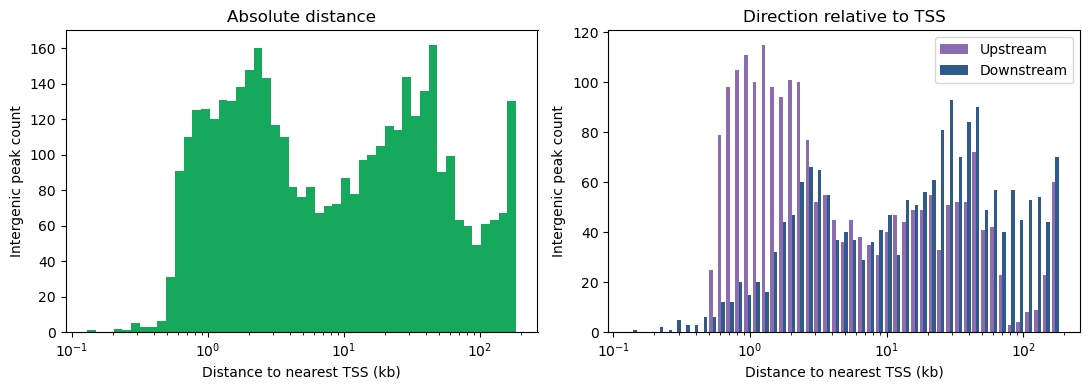

In [6]:
distance_kb = intergenic['abs_tss_distance_bp'] / 1000
bins = np.geomspace(distance_kb[distance_kb > 0].min(), distance_kb.max(), 50)
upstream_kb = distance_kb[intergenic['tss_distance_bp'] < 0]
downstream_kb = distance_kb[intergenic['tss_distance_bp'] >= 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(distance_kb, bins=bins, color='#16a85b')
axes[0].set_xscale('log')
axes[0].set(xlabel='Distance to nearest TSS (kb)', ylabel='Intergenic peak count', title='Absolute distance')
axes[1].hist([upstream_kb, downstream_kb], bins=bins, label=['Upstream', 'Downstream'], color=['#8c6bb1', '#2f5b8c'])
axes[1].set_xscale('log')
axes[1].set(xlabel='Distance to nearest TSS (kb)', ylabel='Intergenic peak count', title='Direction relative to TSS')
axes[1].legend()
plt.tight_layout()

## BAF60 在 genes 和 TSSs 上的 profiles

在全部 33,326 个 GTF genes 上计算平均 `log2(IP/Input)`，不进行信号过滤。Gene bodies 统一 scale 到 5 kb，两个矩阵均包含上下游 2 kb flanks。

In [7]:
def read_signal_matrix(path):
    with gzip.open(path, 'rt') as f:
        matrix_metadata = json.loads(f.readline().removeprefix('@'))
    matrix = pd.read_csv(path, sep='\t', comment='@', header=None)
    return matrix_metadata, matrix.iloc[:, 6:].to_numpy(float)

gene_body_path = matrix_path.parent.parent / 'compute_matrix_gene_body/BAF60.gene_body.matrix.gz'
tss_path = matrix_path.parent.parent / 'compute_matrix_TSS/BAF60.TSS.matrix.gz'
gene_body_metadata, gene_body_signal = read_signal_matrix(gene_body_path)
tss_metadata, tss_signal = read_signal_matrix(tss_path)
print('gene body:', gene_body_signal.shape, 'TSS:', tss_signal.shape)

gene body: (33326, 450) TSS: (33326, 200)


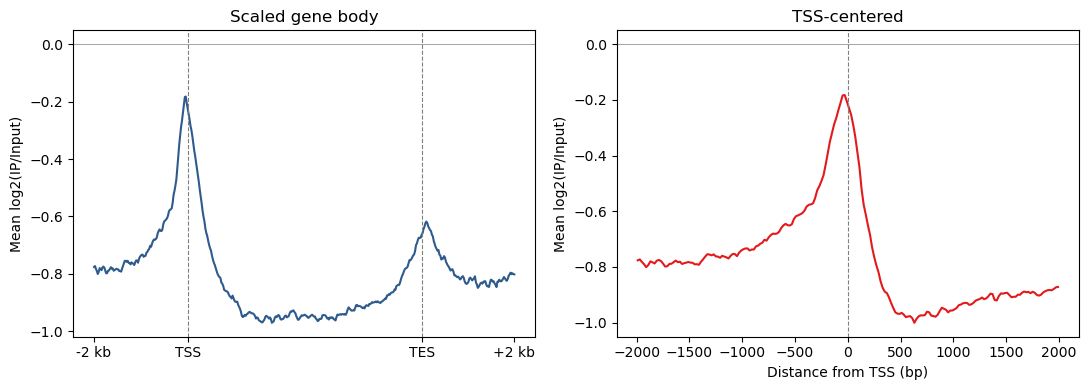

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

gene_profile = np.nanmean(gene_body_signal, axis=0)
axes[0].plot(gene_profile, color='#2f5b8c')
axes[0].axvline(100, color='grey', ls='--', lw=0.8)
axes[0].axvline(350, color='grey', ls='--', lw=0.8)
axes[0].axhline(0, color='grey', lw=0.5)
axes[0].set_xticks([0, 100, 350, 449], ['-2 kb', 'TSS', 'TES', '+2 kb'])
axes[0].set(ylabel='Mean log2(IP/Input)', title='Scaled gene body')

tss_x = np.arange(-2000, 2000, 20) + 10
axes[1].plot(tss_x, np.nanmean(tss_signal, axis=0), color='#e31a1c')
axes[1].axvline(0, color='grey', ls='--', lw=0.8)
axes[1].axhline(0, color='grey', lw=0.5)
axes[1].set(xlabel='Distance from TSS (bp)', ylabel='Mean log2(IP/Input)', title='TSS-centered')
plt.tight_layout()

## BAF60 peaks 涉及的基因数

按照链方向定义两种目标区域，均不向 TES 下游延伸：**宽松型为 TSS 上游 1 kb + gene body**，**较严型为 TSS 上游 500 bp + gene body**。两种定义均分别统计：（1）完整 MACS2 `narrowPeak` 与区域发生任意重叠；（2）1 bp 的 MACS2 summit 落在区域内。由于原文使用 HOMER 注释 peaks，这里也同时给出最近 TSS 的分配结果。

In [9]:
def make_target_regions(upstream):
    regions = genes[['chrom', 'start', 'end', 'strand', 'gene_id']].copy()
    regions['region_start'] = np.maximum(np.where(regions['strand'] == '+',
                                                  regions['start'] - upstream,
                                                  regions['start']), 0)
    regions['region_end'] = np.where(regions['strand'] == '+',
                                     regions['end'],
                                     regions['end'] + upstream)
    return regions

loose_regions = make_target_regions(1000)
strict_regions = make_target_regions(500)
summit_path = peak_path.with_name('BAF60_summits.bed')
summits = pd.read_csv(summit_path, sep='\t', header=None, usecols=[0, 1, 2],
                      names=['chrom', 'start', 'end'])

def count_overlaps(regions, target_regions):
    hit_genes, hit_regions = set(), set()
    for chrom, chrom_genes in target_regions.groupby('chrom'):
        chrom_regions = regions[regions['chrom'] == chrom].sort_values('start')
        starts = chrom_regions['start'].to_numpy()
        ends = chrom_regions['end'].to_numpy()
        indices = chrom_regions.index.to_numpy()
        for gene in chrom_genes.itertuples():
            stop = np.searchsorted(starts, gene.region_end)
            overlaps = indices[:stop][ends[:stop] > gene.region_start]
            if len(overlaps):
                hit_genes.add(gene.gene_id)
                hit_regions.update(overlaps)
    return len(hit_regions), len(hit_genes)

loose_peak_hits, loose_peak_genes = count_overlaps(peaks, loose_regions)
loose_summit_hits, loose_summit_genes = count_overlaps(summits, loose_regions)
strict_peak_hits, strict_peak_genes = count_overlaps(peaks, strict_regions)
strict_summit_hits, strict_summit_genes = count_overlaps(summits, strict_regions)

nearest_genes = set()
for chrom, chrom_summits in summits.groupby('chrom'):
    chrom_tss = tss[tss['chrom'] == chrom].sort_values('tss').reset_index(drop=True)
    positions = chrom_summits['start'].to_numpy()
    tss_positions = chrom_tss['tss'].to_numpy()
    right = np.clip(np.searchsorted(tss_positions, positions), 0, len(tss_positions) - 1)
    left = np.clip(right - 1, 0, len(tss_positions) - 1)
    nearest = np.where(np.abs(tss_positions[right] - positions) <
                       np.abs(tss_positions[left] - positions), right, left)
    nearest_genes.update(chrom_tss.iloc[nearest]['gene_id'])

paper_peaks, paper_genes = 5853, 3729
comparison = pd.DataFrame({
    '统计定义': ['原文（HOMER）', '宽松型：完整 narrowPeak overlap',
                 '宽松型：summit-in-region', '较严型：完整 narrowPeak overlap',
                 '较严型：summit-in-region', '最近 TSS'],
    'peak 总数': [paper_peaks, len(peaks), len(summits), len(peaks), len(summits), len(summits)],
    '区域内 peak/summit 数': [np.nan, loose_peak_hits, loose_summit_hits,
                               strict_peak_hits, strict_summit_hits, len(summits)],
    '涉及的不同基因数': [paper_genes, loose_peak_genes, loose_summit_genes,
                           strict_peak_genes, strict_summit_genes, len(nearest_genes)]
})
comparison['相对原文的基因数差值'] = comparison['涉及的不同基因数'] - paper_genes
display(comparison)
print(f'当前 peak 数相对原文：{len(peaks) - paper_peaks:+,}（{(len(peaks) / paper_peaks - 1) * 100:+.1f}%）')
print(f'宽松型完整 peak 涉及基因数相对原文：{loose_peak_genes - paper_genes:+,}（{(loose_peak_genes / paper_genes - 1) * 100:+.1f}%）')
print(f'较严型完整 peak 涉及基因数相对原文：{strict_peak_genes - paper_genes:+,}（{(strict_peak_genes / paper_genes - 1) * 100:+.1f}%）')

,统计定义,peak 总数,区域内 peak/summit 数,涉及的不同基因数,相对原文的基因数差值
0,原文（HOMER）,5853,NaN,3729,0
1,宽松型：完整 narrowPeak overlap,6490,2297.0,2379,-1350
2,宽松型：summit-in-region,6490,2227.0,2153,-1576
3,较严型：完整 narrowPeak overlap,6490,1837.0,1934,-1795
4,较严型：summit-in-region,6490,1750.0,1697,-2032
5,最近 TSS,6490,6490.0,2593,-1136


当前 peak 数相对原文：+637（+10.9%）
宽松型完整 peak 涉及基因数相对原文：-1,350（-36.2%）
较严型完整 peak 涉及基因数相对原文：-1,795（-48.1%）


### 结果总结

- 当前分析检出 **6,490 个显著 peaks**，原文为 **5,853 个**；当前多 637 个（**+10.9%**）。因此 peak 总数与原文相差不远，并不支持简单的峰检出不足。
- **宽松型（TSS upstream 1 kb + gene body）**：2,297 个完整 peaks overlap 2,379 个基因，占全部 33,326 个基因的 7.1%；相比原文少 1,350 个基因（-36.2%）。按 summit-in-region 统计时，2,227 个 summits 落在 2,153 个基因内。
- **较严型（TSS upstream 500 bp + gene body）**：1,837 个完整 peaks overlap 1,934 个基因，占全部基因的 5.8%；相比原文少 1,795 个基因（-48.1%）。按 summit-in-region 统计时，1,750 个 summits 落在 1,697 个基因内。
- 将每个 summit 不设距离限制地分配给最近 TSS，可得到 **2,593 个不同基因**。
- 因此主要差异不是检出的 peaks 太少。我们的 peaks 涉及的不同基因更少，说明它们更集中地重复分布在部分基因附近，或者更多位于所定义基因区间以外。
- 目前还不是完全同口径比较：原文使用 HOMER 和 TAIR10 做 peak 注释，我们的主要统计则使用明确的区间重叠规则和当前 Araport11 GTF。GEO 仅提供作者处理后的 WIG 轨道，没有作者的 peak BED，因此无法直接按我们的区间规则重新计算原文的 3,729 个基因。

原文：[Jégu 等，Genome Biology（2017）](https://doi.org/10.1186/s13059-017-1246-7)；数据：[GEO GSE89346](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE89346)。

## MAPQ30 过滤后的 peak 分布

这里用完全相同的 Araport11 注释和区间定义比较原始 BAM 与过滤后 BAM 的 MACS2 peaks。过滤条件为 `MAPQ >= 30`，并去除 unmapped、secondary 和 supplementary alignments；此处没有去除 PCR duplicates。

,Original peaks,Original %,MAPQ30 peaks,MAPQ30 %,Change (percentage points)
category,,,,,
Exon,1609,24.79,1160,28.96,4.16
Intron,112,1.73,98,2.45,0.72
Upstream 500,675,10.40,803,20.04,9.64
Intergenic,4094,63.08,1945,48.55,-14.53


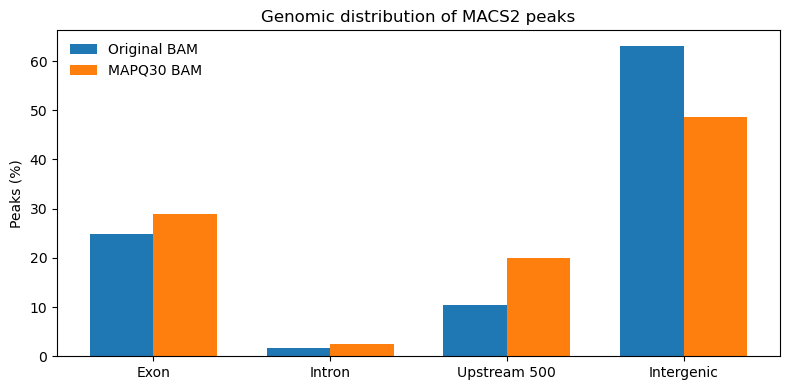

In [10]:
filtered_peak_path = Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow_unique_mapq30/macs2/BAF60/BAF60_peaks.narrowPeak')
filtered_summit_path = filtered_peak_path.with_name('BAF60_summits.bed')
filtered_peaks = pd.read_csv(filtered_peak_path, sep='\t', header=None, usecols=[0, 1, 2],
                              names=['chrom', 'start', 'end'])
filtered_summits = pd.read_csv(filtered_summit_path, sep='\t', header=None, usecols=[0, 1, 2],
                                names=['chrom', 'start', 'end'])
filtered_peaks['category'] = [categories[int(genome_label[c][s:e].min())]
                              for c, s, e in filtered_peaks.itertuples(index=False, name=None)]

original_counts = peaks['category'].value_counts().reindex(categories, fill_value=0)
filtered_counts = filtered_peaks['category'].value_counts().reindex(categories, fill_value=0)
category_comparison = pd.DataFrame({
    'Original peaks': original_counts,
    'Original %': original_counts / len(peaks) * 100,
    'MAPQ30 peaks': filtered_counts,
    'MAPQ30 %': filtered_counts / len(filtered_peaks) * 100
})
category_comparison['Change (percentage points)'] = (category_comparison['MAPQ30 %'] -
                                                    category_comparison['Original %'])
display(category_comparison.round(2))

x = np.arange(len(categories))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, category_comparison['Original %'], width, label='Original BAM')
ax.bar(x + width / 2, category_comparison['MAPQ30 %'], width, label='MAPQ30 BAM')
ax.set(xticks=x, xticklabels=categories, ylabel='Peaks (%)', title='Genomic distribution of MACS2 peaks')
ax.legend(frameon=False)
plt.tight_layout()

,Distance to nearest TSS (kb),Original intergenic peaks within distance (%),MAPQ30 intergenic peaks within distance (%)
0,1,11.63,24.88
1,2,26.65,57.94
2,5,44.77,93.37
3,10,53.18,96.66
4,20,63.95,97.69
5,50,83.98,99.23


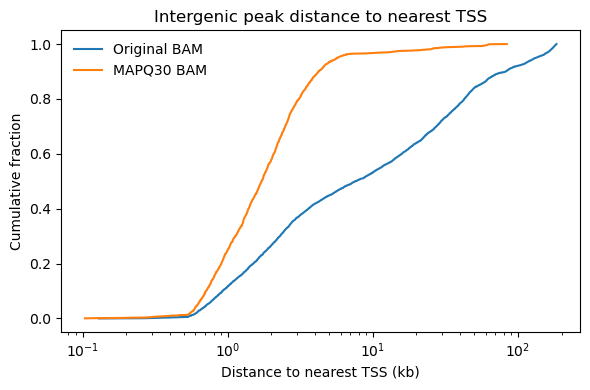

In [11]:
def nearest_tss_distances(regions):
    distances = []
    regions = regions.copy()
    regions['midpoint'] = ((regions['start'] + regions['end']) // 2).astype(int)
    for chrom, group in regions.groupby('chrom'):
        tss_positions = np.sort(tss.loc[tss['chrom'] == chrom, 'tss'].to_numpy())
        positions = group['midpoint'].to_numpy()
        right = np.clip(np.searchsorted(tss_positions, positions), 0, len(tss_positions) - 1)
        left = np.clip(right - 1, 0, len(tss_positions) - 1)
        distances.extend(np.minimum(abs(tss_positions[right] - positions),
                                    abs(tss_positions[left] - positions)))
    return np.asarray(distances)

original_intergenic_distance = nearest_tss_distances(peaks[peaks['category'] == 'Intergenic'])
filtered_intergenic_distance = nearest_tss_distances(filtered_peaks[filtered_peaks['category'] == 'Intergenic'])
thresholds_kb = np.array([1, 2, 5, 10, 20, 50])
distance_comparison = pd.DataFrame({
    'Distance to nearest TSS (kb)': thresholds_kb,
    'Original intergenic peaks within distance (%)':
        [(original_intergenic_distance <= x * 1000).mean() * 100 for x in thresholds_kb],
    'MAPQ30 intergenic peaks within distance (%)':
        [(filtered_intergenic_distance <= x * 1000).mean() * 100 for x in thresholds_kb]
})
display(distance_comparison.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
for values, label in [(original_intergenic_distance, 'Original BAM'),
                      (filtered_intergenic_distance, 'MAPQ30 BAM')]:
    values = np.sort(values / 1000)
    ax.plot(values, np.arange(1, len(values) + 1) / len(values), label=label)
ax.set_xscale('log')
ax.set(xlabel='Distance to nearest TSS (kb)', ylabel='Cumulative fraction',
       title='Intergenic peak distance to nearest TSS')
ax.legend(frameon=False)
plt.tight_layout()

In [12]:
def overlap_members(regions, target_regions):
    hit_genes, hit_regions = set(), set()
    for chrom, chrom_genes in target_regions.groupby('chrom'):
        chrom_regions = regions[regions['chrom'] == chrom].sort_values('start')
        starts = chrom_regions['start'].to_numpy()
        ends = chrom_regions['end'].to_numpy()
        indices = chrom_regions.index.to_numpy()
        for gene in chrom_genes.itertuples():
            stop = np.searchsorted(starts, gene.region_end)
            overlaps = indices[:stop][ends[:stop] > gene.region_start]
            if len(overlaps):
                hit_genes.add(gene.gene_id)
                hit_regions.update(overlaps)
    return hit_regions, hit_genes

target_rows = []
for definition, target_regions in [('Loose: TSS -1 kb + gene body', loose_regions),
                                   ('Strict: TSS -500 bp + gene body', strict_regions)]:
    for region_type, original_regions, mapq30_regions in [
        ('narrowPeak overlap', peaks, filtered_peaks),
        ('summit in region', summits, filtered_summits)]:
        original_hits, original_genes = overlap_members(original_regions, target_regions)
        mapq30_hits, mapq30_genes = overlap_members(mapq30_regions, target_regions)
        target_rows.append([definition, region_type, len(original_hits), len(mapq30_hits),
                            len(original_genes), len(mapq30_genes), len(original_genes & mapq30_genes),
                            len(original_genes - mapq30_genes), len(mapq30_genes - original_genes)])
target_comparison = pd.DataFrame(target_rows, columns=[
    'Target definition', 'Peak definition', 'Original peaks in region', 'MAPQ30 peaks in region',
    'Original genes', 'MAPQ30 genes', 'Shared genes', 'Original-only genes', 'MAPQ30-only genes'])
display(target_comparison)

def interval_overlap_mask(query, reference):
    result = pd.Series(False, index=query.index)
    for chrom, group in query.groupby('chrom'):
        ref = reference[reference['chrom'] == chrom].sort_values('start')
        ref_starts, ref_ends = ref['start'].to_numpy(), ref['end'].to_numpy()
        for row in group.itertuples():
            stop = np.searchsorted(ref_starts, row.end)
            result.loc[row.Index] = np.any(ref_ends[:stop] > row.start)
    return result

original_overlap = interval_overlap_mask(peaks, filtered_peaks)
filtered_overlap = interval_overlap_mask(filtered_peaks, peaks)
peak_set_overlap = pd.DataFrame({
    'Peak set': ['Original BAM', 'MAPQ30 BAM'],
    'Total peaks': [len(peaks), len(filtered_peaks)],
    'Peaks overlapping the other set': [original_overlap.sum(), filtered_overlap.sum()]
})
peak_set_overlap['Overlap %'] = (peak_set_overlap['Peaks overlapping the other set'] /
                                 peak_set_overlap['Total peaks'] * 100)
display(peak_set_overlap.round(2))

,Target definition,Peak definition,Original peaks in region,MAPQ30 peaks in region,Original genes,MAPQ30 genes,Shared genes,Original-only genes,MAPQ30-only genes
0,Loose: TSS -1 kb + gene body,narrowPeak overlap,2297,2540,2379,2490,1899,480,591
1,Loose: TSS -1 kb + gene body,summit in region,2227,2457,2153,2314,1712,441,602
2,Strict: TSS -500 bp + gene body,narrowPeak overlap,1837,2061,1934,2002,1518,416,484
3,Strict: TSS -500 bp + gene body,summit in region,1750,1954,1697,1807,1322,375,485


,Peak set,Total peaks,Peaks overlapping the other set,Overlap %
0,Original BAM,6490,2844,43.82
1,MAPQ30 BAM,4006,2824,70.49


### TSS -500 bp + gene body 结合基因的交集

这里使用完整 `narrowPeak` 与 `TSS upstream 500 bp + gene body` 相交来定义有结合峰的基因。

,Gene set,Genes
0,Original only,416
1,Shared,1518
2,MAPQ30 only,484
3,Original total,1934
4,MAPQ30 total,2002


,Original,MAPQ30,Membership
gene_id,,,
AT1G01010,False,True,MAPQ30 only
AT1G01340,True,True,Shared
AT1G01350,True,True,Shared
AT1G01370,True,True,Shared
AT1G01420,True,True,Shared


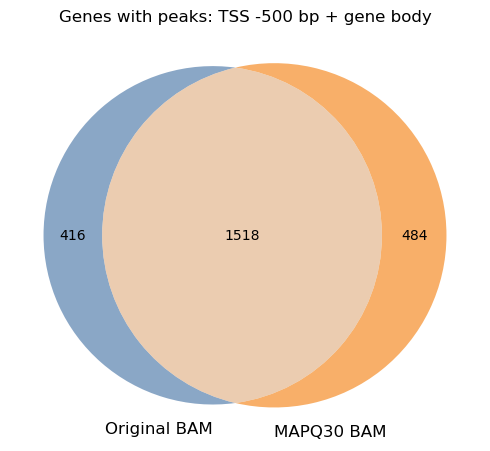

In [13]:
from matplotlib_venn import venn2

_, original_tss500_genes = overlap_members(peaks, strict_regions)
_, mapq30_tss500_genes = overlap_members(filtered_peaks, strict_regions)
shared_tss500_genes = original_tss500_genes & mapq30_tss500_genes
original_only_tss500_genes = original_tss500_genes - mapq30_tss500_genes
mapq30_only_tss500_genes = mapq30_tss500_genes - original_tss500_genes

tss500_gene_summary = pd.DataFrame({
    'Gene set': ['Original only', 'Shared', 'MAPQ30 only', 'Original total', 'MAPQ30 total'],
    'Genes': [len(original_only_tss500_genes), len(shared_tss500_genes),
              len(mapq30_only_tss500_genes), len(original_tss500_genes),
              len(mapq30_tss500_genes)]
})
display(tss500_gene_summary)

tss500_gene_membership = pd.DataFrame(index=sorted(original_tss500_genes | mapq30_tss500_genes))
tss500_gene_membership.index.name = 'gene_id'
tss500_gene_membership['Original'] = tss500_gene_membership.index.isin(original_tss500_genes)
tss500_gene_membership['MAPQ30'] = tss500_gene_membership.index.isin(mapq30_tss500_genes)
tss500_gene_membership['Membership'] = np.select(
    [tss500_gene_membership['Original'] & tss500_gene_membership['MAPQ30'],
     tss500_gene_membership['Original']],
    ['Shared', 'Original only'], default='MAPQ30 only')
display(tss500_gene_membership.head())

fig, ax = plt.subplots(figsize=(5, 5))
venn2([original_tss500_genes, mapq30_tss500_genes],
      set_labels=('Original BAM', 'MAPQ30 BAM'), ax=ax,
      set_colors=('#4C78A8', '#F58518'), alpha=0.65)
ax.set_title('Genes with peaks: TSS -500 bp + gene body')
plt.tight_layout()

原始 BAM 得到 1,934 个结合基因，MAPQ30 BAM 得到 2,002 个；其中 **1,518 个共有**、**416 个仅见于原始 BAM**、**484 个仅见于 MAPQ30 BAM**。并集为 2,418 个基因，Jaccard 相似度为 62.8%。MAPQ30 后基因总数相近但有约三分之一的并集成员发生变化，进一步说明重新 callpeak 后不是简单地从原 peak/gene 集合中删去一部分。

### MAPQ30 结果小结

- 过滤后 MACS2 peaks 从 **6,490** 降至 **4,006**（减少 38.3%）。
- **Intergenic** 比例从 **63.1%** 降至 **48.6%**；**Upstream 500** 从 **10.4%** 升至 **20.0%**，Exon 从 24.8% 升至 29.0%。这说明 MAPQ30 过滤明显改变了 peak 分布，但 MAPQ 本身不能等同于 strict unique mapping。
- 剩余 intergenic peaks 也明显更靠近基因：距最近 TSS 5 kb 内的比例从 **44.8%** 升至 **93.4%**。这说明过滤不仅减少 intergenic peak 数量，也优先移除了远离注释基因的 peaks。
- 过滤后的 peaks 并不是原 peaks 的简单子集：2,824/4,006（70.5%）过滤后 peaks 与原 peaks overlap，而原 peaks 中 2,844/6,490（43.8%）与过滤后 peaks overlap。重新 callpeak 会同时改变局部背景、显著性和 peak 边界。
- 宽松型定义下，完整 peaks 涉及的基因数从 **2,379** 增至 **2,490**；较严型从 **1,934** 增至 **2,002**。虽然 peak 总数下降，基因相关 peaks 的比例和涉及基因数反而略升，说明过滤主要压低了 intergenic peaks，并重新组织了 peak calling 结果。
- 与原文 3,729 个靶基因相比，过滤后宽松型仍少 1,239 个（-33.2%），差距有所缩小但没有消失。下一节继续加入 Bowtie2 MAPQ30 + no-XS 结果；`XS` 表示 Bowtie2 找到次优 alignment，因此 no-XS 比单独 MAPQ30 更接近作者所说的 unique mapping，但仍不是穷举式唯一性证明。

## 三种 BAM 处理方式的 peak 比较

统一比较原始 BAM、MAPQ30 primary BAM，以及 MAPQ30 后进一步去除 Bowtie2 `XS:i` alignment 的 BAM。三套结果使用相同 MACS2 和下游参数。

,Peaks,Median width (bp),Median signalValue,Median -log10(q-value)
Method,,,,
Original,6490,86.0,4.45,4.18
MAPQ30,4006,95.0,4.54,3.50
MAPQ30 + no XS,5582,282.0,3.75,5.09


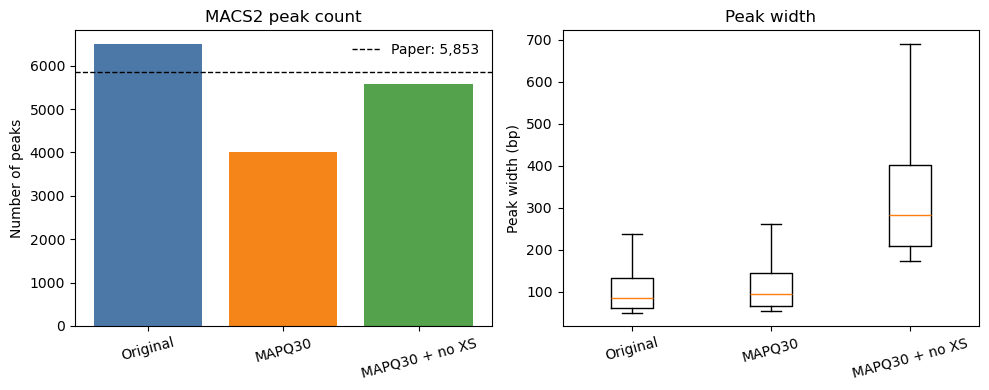

In [14]:
noxs_peak_path = Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow_mapq30_noXS/macs2/BAF60/BAF60_peaks.narrowPeak')
noxs_summit_path = noxs_peak_path.with_name('BAF60_summits.bed')
noxs_peaks = pd.read_csv(noxs_peak_path, sep='\t', header=None, usecols=[0, 1, 2],
                         names=['chrom', 'start', 'end'])
noxs_summits = pd.read_csv(noxs_summit_path, sep='\t', header=None, usecols=[0, 1, 2],
                           names=['chrom', 'start', 'end'])
noxs_peaks['category'] = [categories[int(genome_label[c][s:e].min())]
                          for c, s, e in noxs_peaks.itertuples(index=False, name=None)]

method_order = ['Original', 'MAPQ30', 'MAPQ30 + no XS']
method_peaks = {'Original': peaks, 'MAPQ30': filtered_peaks, 'MAPQ30 + no XS': noxs_peaks}
method_summits = {'Original': summits, 'MAPQ30': filtered_summits, 'MAPQ30 + no XS': noxs_summits}
detail_columns = ['chrom', 'start', 'end', 'name', 'score', 'strand',
                  'signalValue', 'pValue', 'qValue', 'summitOffset']
detail_paths = {'Original': peak_path, 'MAPQ30': filtered_peak_path, 'MAPQ30 + no XS': noxs_peak_path}
peak_details = {name: pd.read_csv(path, sep='\t', names=detail_columns)
                for name, path in detail_paths.items()}

peak_properties = pd.DataFrame([{
    'Method': name, 'Peaks': len(table),
    'Median width (bp)': (table['end'] - table['start']).median(),
    'Median signalValue': table['signalValue'].median(),
    'Median -log10(q-value)': table['qValue'].median()
} for name, table in peak_details.items()]).set_index('Method')
display(peak_properties.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(method_order, peak_properties.loc[method_order, 'Peaks'],
            color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].axhline(5853, color='black', linestyle='--', linewidth=1, label='Paper: 5,853')
axes[0].set(ylabel='Number of peaks', title='MACS2 peak count')
axes[0].legend(frameon=False)
axes[1].boxplot([(peak_details[name]['end'] - peak_details[name]['start']) for name in method_order],
                tick_labels=method_order, showfliers=False)
axes[1].set(ylabel='Peak width (bp)', title='Peak width')
for ax in axes:
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()

Peak count                         Peak %                      
               Original MAPQ30 MAPQ30 + no XS Original MAPQ30 MAPQ30 + no XS
category                                                                    
Exon               1609   1160           2489    24.79  28.96          44.59
Intron              112     98            125     1.73   2.45           2.24
Upstream 500        675    803            942    10.40  20.04          16.88
Intergenic         4094   1945           2026    63.08  48.55          36.30

,Intergenic peaks,Median distance to TSS (kb),Within 5 kb (%),Within 10 kb (%)
Method,,,,
Original,4094,7.61,44.77,53.18
MAPQ30,1945,1.72,93.37,96.66
MAPQ30 + no XS,2026,1.70,96.54,99.90


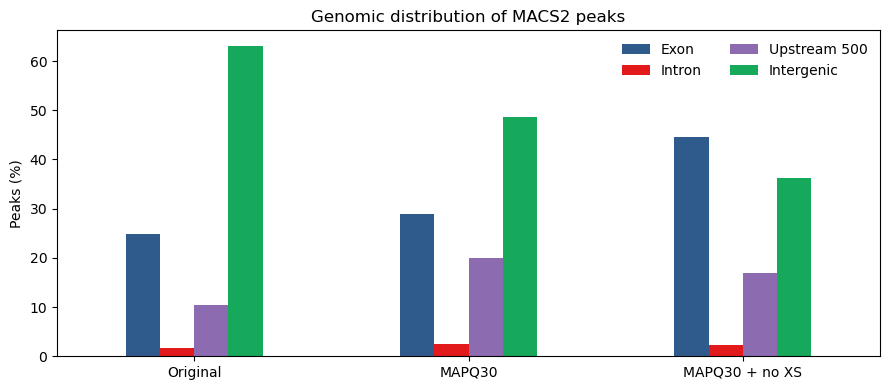

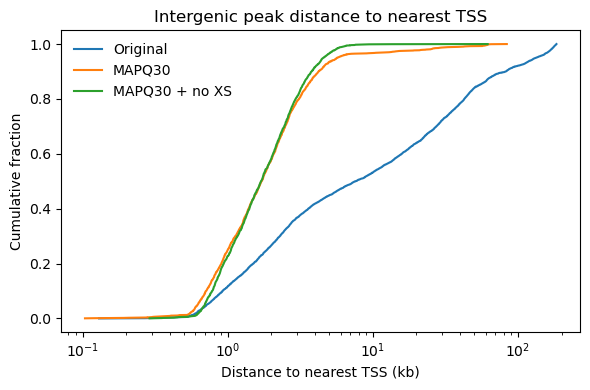

In [15]:
three_category_counts = pd.DataFrame({
    name: table['category'].value_counts().reindex(categories, fill_value=0)
    for name, table in method_peaks.items()
})
three_category_percent = three_category_counts / three_category_counts.sum(axis=0) * 100
display(pd.concat({'Peak count': three_category_counts, 'Peak %': three_category_percent.round(2)}, axis=1))

ax = three_category_percent.T.loc[method_order].plot.bar(figsize=(9, 4), color=colors)
ax.set(xlabel='', ylabel='Peaks (%)', title='Genomic distribution of MACS2 peaks')
ax.tick_params(axis='x', rotation=0)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()

three_distance = {name: nearest_tss_distances(table[table['category'] == 'Intergenic'])
                  for name, table in method_peaks.items()}
distance_summary = pd.DataFrame([{
    'Method': name, 'Intergenic peaks': len(values),
    'Median distance to TSS (kb)': np.median(values) / 1000,
    'Within 5 kb (%)': (values <= 5000).mean() * 100,
    'Within 10 kb (%)': (values <= 10000).mean() * 100
} for name, values in three_distance.items()]).set_index('Method')
display(distance_summary.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
for name in method_order:
    values = np.sort(three_distance[name] / 1000)
    ax.plot(values, np.arange(1, len(values) + 1) / len(values), label=name)
ax.set_xscale('log')
ax.set(xlabel='Distance to nearest TSS (kb)', ylabel='Cumulative fraction',
       title='Intergenic peak distance to nearest TSS')
ax.legend(frameon=False)
plt.tight_layout()

Reference peaks,Original,MAPQ30,MAPQ30 + no XS
Query peaks,,,
Original,100.00,43.82,42.25
MAPQ30,70.49,100.00,91.36
MAPQ30 + no XS,38.39,51.09,100.00


Reference summits,Original,MAPQ30,MAPQ30 + no XS
Query summits,,,
Original,100.00,41.34,26.92
MAPQ30,66.95,100.00,58.29
MAPQ30 + no XS,30.80,41.22,100.00


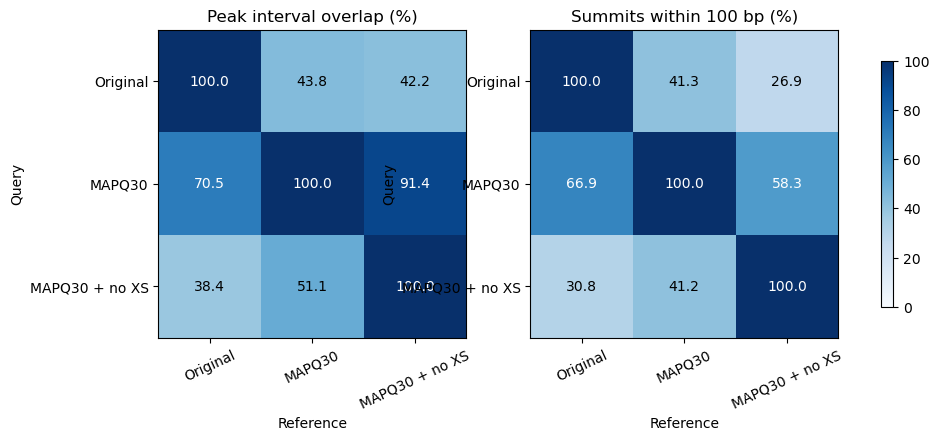

In [16]:
peak_overlap_percent = pd.DataFrame(index=method_order, columns=method_order, dtype=float)
for query_name in method_order:
    for reference_name in method_order:
        peak_overlap_percent.loc[query_name, reference_name] = (
            interval_overlap_mask(method_peaks[query_name], method_peaks[reference_name]).mean() * 100)

def summit_proximity_percent(query, reference, distance=100):
    hits = 0
    for chrom, group in query.groupby('chrom'):
        reference_positions = np.sort(reference.loc[reference['chrom'] == chrom, 'start'].to_numpy())
        for position in group['start']:
            right = np.searchsorted(reference_positions, position)
            nearby = []
            if right < len(reference_positions):
                nearby.append(abs(reference_positions[right] - position))
            if right > 0:
                nearby.append(abs(reference_positions[right - 1] - position))
            hits += bool(nearby and min(nearby) <= distance)
    return hits / len(query) * 100

summit_overlap_percent = pd.DataFrame(index=method_order, columns=method_order, dtype=float)
for query_name in method_order:
    for reference_name in method_order:
        summit_overlap_percent.loc[query_name, reference_name] = summit_proximity_percent(
            method_summits[query_name], method_summits[reference_name], distance=100)
display(peak_overlap_percent.round(2).rename_axis('Query peaks').rename_axis('Reference peaks', axis=1))
display(summit_overlap_percent.round(2).rename_axis('Query summits').rename_axis('Reference summits', axis=1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, matrix, title in [(axes[0], peak_overlap_percent, 'Peak interval overlap (%)'),
                          (axes[1], summit_overlap_percent, 'Summits within 100 bp (%)')]:
    image = ax.imshow(matrix, vmin=0, vmax=100, cmap='Blues')
    ax.set(xticks=range(3), yticks=range(3), xticklabels=method_order, yticklabels=method_order,
           xlabel='Reference', ylabel='Query', title=title)
    ax.tick_params(axis='x', rotation=25)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{matrix.iloc[i, j]:.1f}', ha='center', va='center',
                    color='white' if matrix.iloc[i, j] > 55 else 'black')
fig.colorbar(image, ax=axes, shrink=0.8)
plt.show()

,Target definition,Method,Overlapping peaks,Genes from peak overlap,Summits in region,Genes from summits
0,Loose: TSS -1 kb + gene body,Original,2297,2379,2227,2153
1,Loose: TSS -1 kb + gene body,MAPQ30,2540,2490,2457,2314
2,Loose: TSS -1 kb + gene body,MAPQ30 + no XS,4102,4581,3818,4088
3,Strict: TSS -500 bp + gene body,Original,1837,1934,1750,1697
4,Strict: TSS -500 bp + gene body,MAPQ30,2061,2002,1954,1807
5,Strict: TSS -500 bp + gene body,MAPQ30 + no XS,3555,3946,3146,3339


,Genes
Membership,
MAPQ30 + no XS,2068
Original + MAPQ30 + MAPQ30 + no XS,1440
MAPQ30 + MAPQ30 + no XS,407
Original,385
Original + MAPQ30,78
MAPQ30,77
Original + MAPQ30 + no XS,31


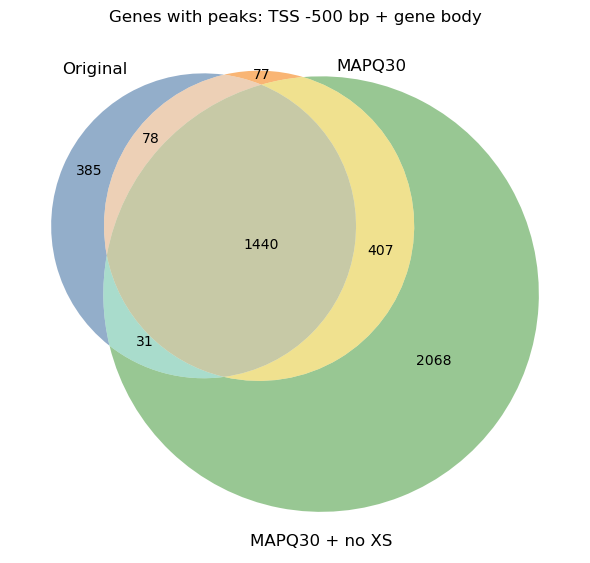

In [17]:
three_target_rows = []
target_gene_sets = {}
for definition, target_regions in [('Loose: TSS -1 kb + gene body', loose_regions),
                                   ('Strict: TSS -500 bp + gene body', strict_regions)]:
    for name in method_order:
        peak_hits, peak_genes = overlap_members(method_peaks[name], target_regions)
        summit_hits, summit_genes = overlap_members(method_summits[name], target_regions)
        three_target_rows.append([definition, name, len(peak_hits), len(peak_genes),
                                  len(summit_hits), len(summit_genes)])
        if definition.startswith('Strict'):
            target_gene_sets[name] = peak_genes
three_target_comparison = pd.DataFrame(three_target_rows, columns=[
    'Target definition', 'Method', 'Overlapping peaks', 'Genes from peak overlap',
    'Summits in region', 'Genes from summits'])
display(three_target_comparison)

from matplotlib_venn import venn3
fig, ax = plt.subplots(figsize=(6, 6))
venn3([target_gene_sets[name] for name in method_order], set_labels=method_order, ax=ax,
      set_colors=('#4C78A8', '#F58518', '#54A24B'), alpha=0.60)
ax.set_title('Genes with peaks: TSS -500 bp + gene body')
plt.tight_layout()

all_target_genes = sorted(set().union(*target_gene_sets.values()))
three_gene_membership = pd.DataFrame(index=all_target_genes)
three_gene_membership.index.name = 'gene_id'
for name in method_order:
    three_gene_membership[name] = three_gene_membership.index.isin(target_gene_sets[name])
three_gene_membership['Membership'] = three_gene_membership[method_order].apply(
    lambda row: ' + '.join(row.index[row]), axis=1)
display(three_gene_membership['Membership'].value_counts().rename('Genes').to_frame())

### 三方案比较小结

- peak 总数依次为 **6,490、4,006、5,582**。no-XS 版比原文 5,853 个少 271 个（-4.6%），是三版中最接近原文的。
- no-XS 版的 **Intergenic 为 36.3%**，低于原始版 63.1% 和 MAPQ30 版 48.6%；Exon 升至 44.6%，Upstream 500 为 16.9%。它仍未复现原文图中的 Upstream 500 = 42%，说明注释方法或 peak-to-feature 优先级仍不一致。
- no-XS intergenic peaks 距最近 TSS 的中位距离为 **1.70 kb**，96.5% 位于最近 TSS 5 kb 内；原始版分别为 7.61 kb 和 44.8%。远离基因的 peak 已大幅减少。
- 较严型 `TSS -500 bp + gene body` 定义得到 **3,946 个基因**，比原文 3,729 个多 217 个（+5.8%）；宽松型得到 4,581 个。较严型数量已经很接近原文，但二者的 peak-to-gene 规则仍非完全同口径。
- 三版较严型靶基因中仅 **1,440 个三者共有**；no-XS 版有 2,068 个特有基因。MAPQ30 peaks 中 91.4% 与 no-XS peaks overlap，但只有 58.3% 的 MAPQ30 summits 距 no-XS summit 100 bp 内，表明不少 peak 区域保留而 summit 位置或边界发生变化。
- 需要特别注意：no-XS 后 MACS2 自动预测的 fragment length 为 **174 bp**，原始和 MAPQ30 版本分别为 51 bp 和 54 bp；no-XS 的中位 peak 宽度也达到 **282 bp**，而前两版为 86 bp 和 95 bp。fragment model 的变化会直接影响 peak 宽度、边界和基因 overlap，因此数量接近原文很有价值，但不能单凭数量断定已经复现。

## MACS2 fragment length `d` 的判断与暂定方案

### 当前证据

| 输入 BAM | 用于建模的 paired peaks | 自动预测 `d` | 判断 |
|---|---:|---:|---|
| Original | 1,628 | 51 bp | 几乎等于 50 bp read length，可能是 read-length/phantom peak |
| MAPQ30 | 338 | 54 bp | 同样接近 read length；MACS2 明确警告 paired peaks 少于 1,000，模型可能不稳 |
| MAPQ30 + no XS | 446 | 174 bp | 更符合常见 ChIP DNA 片段长度，但 MACS2 仍警告模型可能不稳 |

no-XS 模型并没有把片段长度非常尖锐地限定在 174 bp。其备选相关峰为 174、209、217、241 和 267 bp；相对于最高点，相关性分别约为 100%、98.2%、98.0%、96.0% 和 93.2%。因此数据支持的是大致 **174–267 bp 的宽平台**，174 bp 只是其中最高的候选值，并非已经精确确定的真实片段长度。

### 为什么过滤后 `d` 会突变

`d` 不是 BAM 中预先存在的固定属性，而是 MACS2 根据候选富集区域中正、负链 reads 的错位关系现场估计的。去除带 `XS` tag 的 reads 会选择性改变重复区域和多重比对 reads 的组成，也会改变正负链相关曲线。这个 BAF60 IP 的 MACS2 redundant rate 约为 **0.86**，library complexity 偏低；过滤后又只有数百个 paired peaks 用于建模，因此自动模型对输入 reads 很敏感。

`d` 的变化不仅影响 deepTools 的 `--extendReads`。MACS2 还会用预测的 `d` 延伸 SE reads、构建 pileup，并默认将其用于 minimum peak length。因此从 54 bp 变成 174 bp 会改变 peak 的宽度、边界、summit 和最终 peak 数量。no-XS 新增约 2,000 个结合基因不能全部解释成 unique mapping 的效果，其中混入了 fragment model 改变的影响。

### 暂定结论

1. **不采用 51/54 bp 作为最终 fragment length。** 它们太接近 50 bp read length，而且 MACS2 对短于两倍 read length 的 `d` 给出了异常提示。
2. **174 bp 是目前更合理的候选值，但不把它当作已经验证的精确真值。**
3. 当前 no-XS 版的 3,946 个严格定义结合基因只能作为探索性结果，不能直接全部认定为 BAF60 靶基因。
4. 在固定 `d` 对照完成前，可暂时把 MAPQ30 与 no-XS 共同的 **1,847 个严格定义结合基因**作为较保守的候选集合。

### 后续验证方案

- 暂不修改通用 `ChIP_workflow`，在本项目建立诊断分支。
- 对 MAPQ30 和 MAPQ30 + no-XS 两套 BAM 使用完全相同的 `--nomodel --extsize 174` 重新 call peak；对应的 `bamCoverage` 和 `bamCompare` 均统一使用 `--extendReads 174`。这样可以把 unique-read 过滤效应与 MACS2 自动建模效应分开。
- 对 no-XS BAM 进一步测试 `d = 150/174/200/250 bp`。优先保留不同合理 `d` 下均稳定存在的 peaks 和结合基因。
- 如果必须在当前三版结果中选择 signal track，优先查看 no-XS、`d = 174 bp` 版本；涉及 peak 或靶基因结论时则采用稳定交集，并把 no-XS 新增位点标记为待验证候选。

**核心原则：排除明显的 51/54 bp read-length peak，把 174 bp 作为候选固定值；随后统一 `d` 重跑，避免同时改变 mapping filter 和 fragment model。**

## 三种跑法的 gene-body meta profiles

分别比较全部 GTF genes 和每种跑法自身 call 到峰的基因。这里沿用前面的较严定义：该方法的 MACS2 `narrowPeak` 与 **TSS -500 bp + gene body** 发生重叠，即认为该基因有峰。每个 gene body scale 到 5 kb，并保留 TSS 上游和 TES 下游各 2 kb；不额外进行低信号过滤。

,Method,All genes,Genes with peaks
0,Original,33326,1934
1,MAPQ30,33326,2002
2,MAPQ30 + no XS,33326,3946


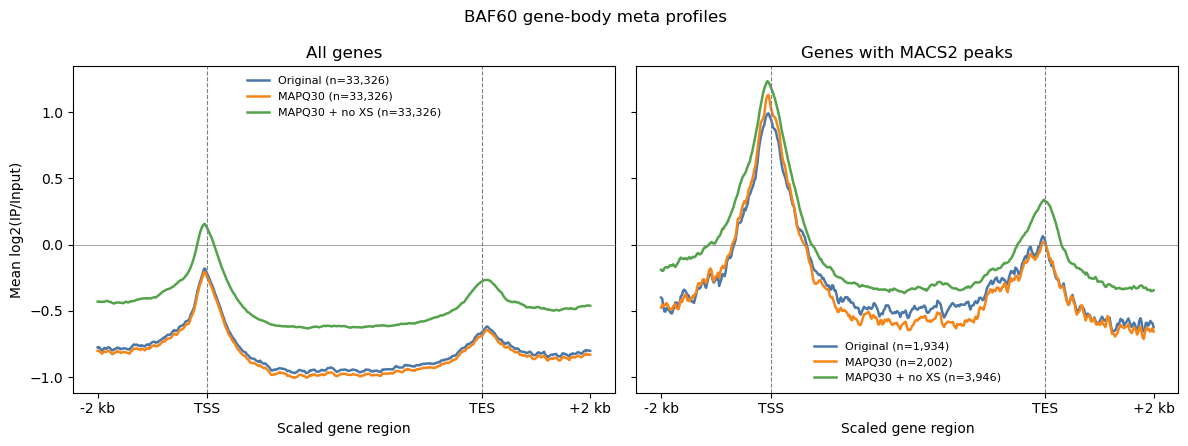

In [18]:
gene_body_matrix_paths = {
    'Original': Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow/compute_matrix_gene_body/BAF60.gene_body.matrix.gz'),
    'MAPQ30': Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow_unique_mapq30/compute_matrix_gene_body/BAF60.gene_body.matrix.gz'),
    'MAPQ30 + no XS': Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow_mapq30_noXS/compute_matrix_gene_body/BAF60.gene_body.matrix.gz'),
}

gene_body_profiles = {}
profile_summary = []
for name, path in gene_body_matrix_paths.items():
    with gzip.open(path, 'rt') as handle:
        meta = json.loads(handle.readline().removeprefix('@'))
    matrix = pd.read_csv(path, sep='\t', comment='@', header=None)
    signal = matrix.iloc[:, 6:].to_numpy(float)
    has_peak = matrix.iloc[:, 3].astype(str).isin(target_gene_sets[name]).to_numpy()
    gene_body_profiles[name] = {
        'all': np.nanmean(signal, axis=0),
        'peak': np.nanmean(signal[has_peak], axis=0),
    }
    profile_summary.append([name, len(matrix), int(has_peak.sum())])

profile_summary = pd.DataFrame(profile_summary, columns=['Method', 'All genes', 'Genes with peaks'])
display(profile_summary)

colors = {'Original': '#4C78A8', 'MAPQ30': '#F58518', 'MAPQ30 + no XS': '#54A24B'}
x_ticks = [0, 100, 350, 449]
x_labels = ['-2 kb', 'TSS', 'TES', '+2 kb']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, subset, title in zip(axes, ['all', 'peak'], ['All genes', 'Genes with MACS2 peaks']):
    for name in method_order:
        n = profile_summary.set_index('Method').loc[name, 'All genes' if subset == 'all' else 'Genes with peaks']
        ax.plot(gene_body_profiles[name][subset], color=colors[name], lw=1.8, label=f'{name} (n={n:,})')
    ax.axvline(100, color='grey', ls='--', lw=0.8)
    ax.axvline(350, color='grey', ls='--', lw=0.8)
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_xticks(x_ticks, x_labels)
    ax.set(xlabel='Scaled gene region', title=title)
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel('Mean log2(IP/Input)')
fig.suptitle('BAF60 gene-body meta profiles')
plt.tight_layout()

## HOMER peak annotation：三种跑法与两套 reference

读取 `annotatePeaks.pl` 的完整输出。每种 MACS2 peak 分别使用 HOMER 自带 tair10 default annotation，以及项目中的 Araport11 2024 GTF。HOMER 的 `promoter-TSS` 默认约为 TSS 上游 1 kb 到下游 100 bp；另外根据 `Distance to TSS` 单独计算真正位于最近 TSS 上游 500 bp 内的 peak 比例。

Peaks  Nearest-TSS upstream 500  promoter-TSS  \
Reference Method                                                          
default   Original         6490                     18.71         37.16   
          MAPQ30           4006                     25.71         49.05   
          MAPQ30 + no XS   5582                     31.69         55.98   
Araport11 Original         6490                     16.39         33.61   
          MAPQ30           4006                     25.96         49.73   
          MAPQ30 + no XS   5582                     31.82         56.41   

                            TTS  exon  intron  Intergenic  
Reference Method                                           
default   Original         9.40  3.00    1.33       49.11  
          MAPQ30          14.83  6.14    2.15       27.83  
          MAPQ30 + no XS  14.33  5.75    2.17       21.77  
Araport11 Original        12.91  9.85    1.65       41.99  
          MAPQ30          15.20  6.17    2.17       26.73  
          MAPQ30 + no XS  14.49  5.73    2.24       21.12

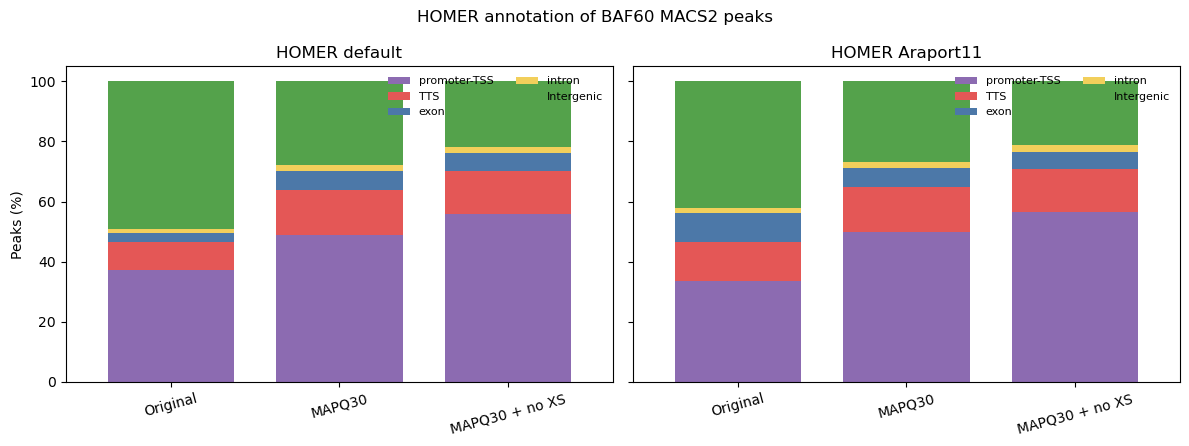

In [19]:
homer_result_dirs = {
    'Original': Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow/homer_annotation'),
    'MAPQ30': Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow_unique_mapq30/homer_annotation'),
    'MAPQ30 + no XS': Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow_mapq30_noXS/homer_annotation'),
}
homer_categories = ['promoter-TSS', 'TTS', 'exon', 'intron', 'Intergenic']
homer_tables = {}
homer_rows = []

for reference in ['default', 'Araport11']:
    for name in method_order:
        path = homer_result_dirs[name] / f'BAF60.annotatedPeaks.{reference}.txt'
        table = pd.read_csv(path, sep='\t', low_memory=False)
        table['Category'] = table['Annotation'].str.replace(r'\s*\(.*$', '', regex=True)
        distance = pd.to_numeric(table['Distance to TSS'], errors='coerce')
        counts = table['Category'].value_counts().reindex(homer_categories, fill_value=0)
        row = {'Reference': reference, 'Method': name, 'Peaks': len(table),
               'Nearest-TSS upstream 500': ((distance >= -500) & (distance < 0)).mean() * 100}
        row.update((counts / len(table) * 100).to_dict())
        homer_rows.append(row)
        homer_tables[(reference, name)] = table

homer_summary = pd.DataFrame(homer_rows)
display(homer_summary.set_index(['Reference', 'Method']).round(2))

annotation_colors = {
    'promoter-TSS': '#8C6BB1', 'TTS': '#E45756', 'exon': '#4C78A8',
    'intron': '#F2CF5B', 'Intergenic': '#54A24B',
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, reference in zip(axes, ['default', 'Araport11']):
    plot_data = homer_summary[homer_summary['Reference'] == reference].set_index('Method').loc[method_order, homer_categories]
    plot_data.plot.bar(stacked=True, ax=ax, color=[annotation_colors[x] for x in homer_categories], width=0.75)
    ax.set(xlabel='', ylabel='Peaks (%)', title=f'HOMER {reference}')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(frameon=False, fontsize=8, ncol=2, loc='upper right')
axes[1].set_ylabel('')
fig.suptitle('HOMER annotation of BAF60 MACS2 peaks')
plt.tight_layout()

promoter-TSS    TTS   Exon  Intron  \
Method         Scheme                                                         
Original       Custom interval priority          0.00   0.00  24.79    1.73   
               HOMER Araport11                  33.61  12.91   9.85    1.65   
MAPQ30         Custom interval priority          0.00   0.00  28.96    2.45   
               HOMER Araport11                  49.73  15.20   6.17    2.17   
MAPQ30 + no XS Custom interval priority          0.00   0.00  44.59    2.24   
               HOMER Araport11                  56.41  14.49   5.73    2.24   

                                         Upstream 500  Intergenic  
Method         Scheme                                              
Original       Custom interval priority         10.40       63.08  
               HOMER Araport11                   0.00       41.99  
MAPQ30         Custom interval priority         20.04       48.55  
               HOMER Araport11                   0.00       26.73  
MAPQ30 + no XS Custom interval priority         16.88       36.30  
               HOMER Araport11                   0.00       21.12

,Custom Upstream 500,HOMER promoter-TSS,HOMER nearest-TSS -500 to 0
Original,10.40,33.61,16.39
MAPQ30,20.04,49.73,25.96
MAPQ30 + no XS,16.88,56.41,31.82


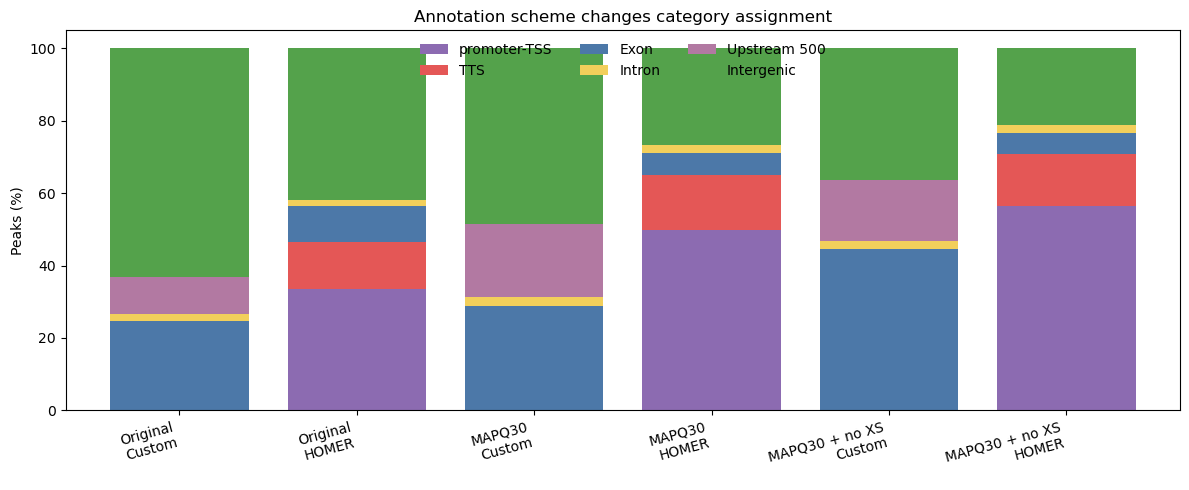

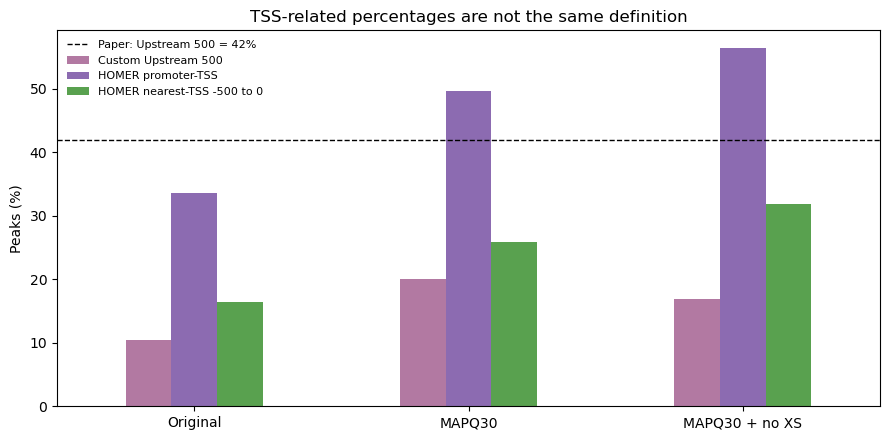

In [20]:
comparison_categories = ['promoter-TSS', 'TTS', 'Exon', 'Intron', 'Upstream 500', 'Intergenic']
comparison_rows = []
for name in method_order:
    custom = three_category_percent[name]
    comparison_rows.append({
        'Method': name, 'Scheme': 'Custom interval priority',
        'promoter-TSS': 0, 'TTS': 0, 'Exon': custom['Exon'], 'Intron': custom['Intron'],
        'Upstream 500': custom['Upstream 500'], 'Intergenic': custom['Intergenic'],
    })
    homer = homer_summary[(homer_summary['Reference'] == 'Araport11') &
                           (homer_summary['Method'] == name)].iloc[0]
    comparison_rows.append({
        'Method': name, 'Scheme': 'HOMER Araport11',
        'promoter-TSS': homer['promoter-TSS'], 'TTS': homer['TTS'],
        'Exon': homer['exon'], 'Intron': homer['intron'],
        'Upstream 500': 0, 'Intergenic': homer['Intergenic'],
    })

annotation_scheme_comparison = pd.DataFrame(comparison_rows).set_index(['Method', 'Scheme'])
display(annotation_scheme_comparison.round(2))

comparison_colors = [annotation_colors['promoter-TSS'], annotation_colors['TTS'],
                     annotation_colors['exon'], annotation_colors['intron'],
                     '#B279A2', annotation_colors['Intergenic']]
ax = annotation_scheme_comparison[comparison_categories].plot.bar(
    stacked=True, figsize=(12, 5), color=comparison_colors, width=0.78)
ax.set(xlabel='', ylabel='Peaks (%)', title='Annotation scheme changes category assignment')
ax.set_xticklabels([f'{method}\n{"Custom" if scheme.startswith("Custom") else "HOMER"}'
                    for method, scheme in annotation_scheme_comparison.index],
                   rotation=15, ha='right')
ax.legend(frameon=False, ncol=3, loc='upper center')
plt.tight_layout()

tss_window_comparison = pd.DataFrame(index=method_order)
tss_window_comparison['Custom Upstream 500'] = three_category_percent.loc['Upstream 500', method_order]
araport_summary = homer_summary[homer_summary['Reference'] == 'Araport11'].set_index('Method').loc[method_order]
tss_window_comparison['HOMER promoter-TSS'] = araport_summary['promoter-TSS']
tss_window_comparison['HOMER nearest-TSS -500 to 0'] = araport_summary['Nearest-TSS upstream 500']
display(tss_window_comparison.round(2))

ax = tss_window_comparison.plot.bar(figsize=(9, 4.5), color=['#B279A2', '#8C6BB1', '#59A14F'])
ax.axhline(42, color='black', ls='--', lw=1, label='Paper: Upstream 500 = 42%')
ax.set(xlabel='', ylabel='Peaks (%)', title='TSS-related percentages are not the same definition')
ax.tick_params(axis='x', rotation=0)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()

### 为什么 HOMER 和自定义优先级差别这么大

1. **窗口不同。** HOMER 的 `promoter-TSS` 默认覆盖约 `TSS -1 kb` 到 `+100 bp`，既比 Upstream 500 更宽，又包含 TSS 下游；它不能直接与原文或自定义分类中的 `Upstream 500` 比较。按 Araport11 的 `Distance to TSS` 真正截取 `-500 <= distance < 0` 后，Original、MAPQ30、no-XS 分别为 **16.4%、26.0%、31.8%**，no-XS 仍未达到原文的 42%。
2. **代表 peak 的位置不同。** HOMER 主要根据 peak 中心位置进行单一分类；自定义代码检查完整 `narrowPeak` 区间是否与 feature 有任意重叠。no-XS 的中位 peak 宽度为 282 bp，完整区间更容易碰到 exon，因此完整区间法尤其容易提高 Exon 比例。
3. **分类优先级不同。** HOMER 优先报告 promoter-TSS，其次再区分 TTS、exon、intron 和 intergenic；自定义规则是 `Exon > Intron > Upstream 500 > Intergenic`，而且没有单列 TTS。同一个同时碰到 promoter 和 exon 的 peak，在两种规则下会被放进完全不同的类别。
4. **reference 不同。** HOMER default 与 Araport11 的 transcript 数量和边界不同。这个影响在 Original 中较明显，但 MAPQ30/no-XS 的两套 HOMER 百分比很接近，说明当前最大的差异来自 peak 集合和分类规则，而不是 default 与 Araport11 的版本差异。

### 哪种更合理

- **复现原文的 peak distribution：优先使用 HOMER default。** 这是最接近原文软件与默认口径的结果；但应把 `promoter-TSS` 明确写成 HOMER promoter category，不能改名成 Upstream 500。若要严格对照原文 Upstream 500，则应按 `Distance to TSS` 重新截取 `-500–0 bp`，并确认原文使用 peak center 还是完整区间。
- **当前项目的功能注释：优先使用 HOMER + Araport11。** 它保留标准、可复现的 peak-level 单一分类，同时采用较新的植物基因注释。对于 narrow ChIP peak，用 summit/peak center 描述结合位置通常比“完整 peak 只要碰到 exon 就算 Exon”更稳健，也较少受 MACS2 peak 宽度和 `d` 影响。
- **定义可能受 BAF60 调控的基因：保留我们的区域 overlap 方法。** `TSS -500 bp + gene body` 与 peak 相交回答的是“哪些基因附近或基因体内存在 peak”，适合生成候选基因集合；但它不是 genomic annotation pie chart，不能与 HOMER 的 promoter/exon 百分比混为一谈。最好同时报告完整 peak overlap 和 summit 落入区域两种数量。

因此不是简单选择 HOMER 或自定义方法之一：**论文复现用 HOMER default，当前 peak annotation 用 HOMER + Araport11，候选靶基因集合继续用显式的 `TSS -500 bp + gene body` overlap。** 现有自定义 `Exon > Intron > Upstream 500` 规则本身可用于特定 overlap 问题，但不建议再作为主要的 peak distribution 分类。